In [4]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm , Normalize

In [5]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters('../parametri.txt')


# --- Parametri Geometrici ---
R_CORE    = p['R_CORE']
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']

# --- Parametri Logici ---
R_PIPE    = p['R_PIPE']

# --- Parametri Pin/Lattice ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']
PITCH     = p['PITCH']

# --- Parametri Target ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']

# --- Sorgente e Simulazione ---
S             = p['S']

bin_ris       = p['bin_ris']
batches       = p['batches_fix']
arricchimento = p['arricchimento']

In [6]:
#Apertura delle tallies
sp = openmc.StatePoint(f'statepoint.{batches}.h5')

Calcolo del volume del core del reattore per la mesh_z 

In [7]:
def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    # Ring 0 è il centro
    for i in range(num_rings):
        ring_radius = i * pitch
        # Se l'anello è fuori dalla pipe centrale e dentro il raggio del core
        if ring_radius >= r_pipe and ring_radius <= r_core:
            if i == 0:
                total_pins += 1
            else:
                total_pins += (6 * i)
    return total_pins

# 1. Calcolo del numero di barre (usando la tua funzione già definita)
n_barre = count_fuel_pins(int(np.ceil(R_CORE / PITCH)) + 1, PITCH, R_PIPE, R_CORE)

# 2. Calcolo del volume analitico reale del bin
A_pin = (3 * np.sqrt(3) / 2) * (R_PIN**2)
A_core = n_barre * A_pin
dz = H_CORE / bin_ris
V = A_core * dz

print(f"Numero di barre: {n_barre}")
print(f"Area totale del core: {A_core:.2f} cm^2")
print(f"Volume reale del reattore: {V*bin_ris:.2f} cm^3")

Numero di barre: 390
Area totale del core: 4258.18 cm^2
Volume reale del reattore: 340654.56 cm^3


Profilo Neutronico e fotonico lungo l'asse del reattore 


OpenMc divide tutto l'asse Z in bin, calcola il flusso per ogni piano del reattore di altezza del bin e lo media, poi plotto il valore della media al variare dell'altezza. 

Entrambi i flussi sono calcolati su tutto il reattore

Il picco fotoni: I fotoni primari subiscono scattering Compton, producendo fotoni secondari che aumentano il conteggio totale della "slice" di mesh. Le interazioni dei fotoni con i nuclei pesanti dell'uranio producono elettroni e positroni energetici che, rallentando nel materiale denso, emettono ulteriori fotoni. I fotoni della sorgente inducono fissioni nel target, le quali rilasciano istantaneamente una cascata di raggi gamma (gamma prompt), creando un "flash" localizzato di radiazione.

Ha senso che la curva dei neutroni, non usi  cell_filter = openmc.CellFilter(c_main_core)?, significa che non si estende SOLO dentro il core, cioè acqua e barre ma anche aria e riflettore esterno...



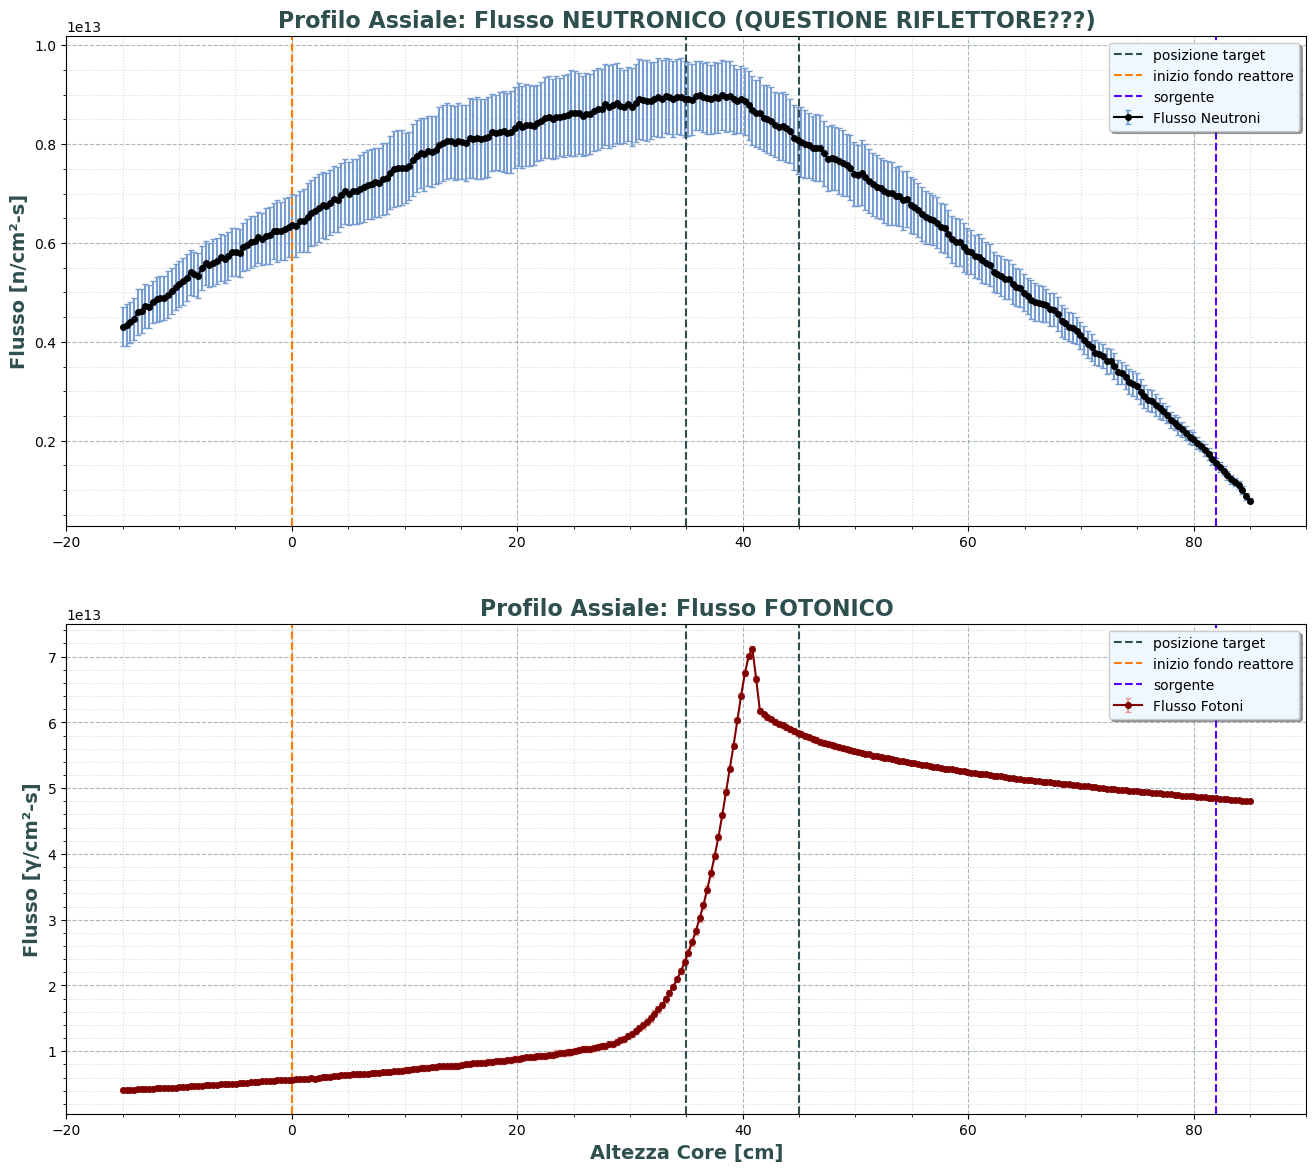

In [8]:
t_n = sp.get_tally(name='profilo_neutroni')
t_p = sp.get_tally(name='profilo_fotoni')

# Neutroni
n_mean = t_n.get_values(scores=['flux'], value='mean').flatten() * S/V
n_std  = t_n.get_values(scores=['flux'], value='std_dev').flatten() * S/V
# Fotoni
p_mean = t_p.get_values(scores=['flux'], value='mean').flatten() * S/V
p_std  = t_p.get_values(scores=['flux'], value='std_dev').flatten() * S/V

# Asse Z
z_coords = np.linspace(-REF_BOT, H_CORE + 5, len(n_mean))

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
plt.subplots_adjust(hspace=0.2)

# --- PLOT 1: NEUTRONI ---
ax1.errorbar(z_coords, n_mean, yerr=n_std, fmt='-o', markersize=4,
             color='#000000', ecolor='#789DD1', capsize=2, label='Flusso Neutroni')
ax1.set_title('Profilo Assiale: Flusso NEUTRONICO (QUESTIONE RIFLETTORE???)', fontsize=16, fontweight='bold', color='#2F4F4F')
ax1.set_ylabel('Flusso [n/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_xlabel('Altezza Core [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax1.minorticks_on()
ax1.axvline(x=P_TARGET + H_TARGET/2 , color='#2F4F4F', linestyle='--', label='posizione target')
ax1.axvline(x=P_TARGET - H_TARGET/2 , color='#2F4F4F', linestyle='--')
ax1.axvline(x=0, color="#FF7B00", linestyle='--', label='inizio fondo reattore')
ax1.axvline(x= H_CORE + 2 , color="#5500FF", linestyle='--', label='sorgente')
ax1.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax1.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax1.legend(loc='upper right', frameon=True, shadow=True, facecolor='#F0F8FF')

# --- PLOT 2: FOTONI ---
ax2.errorbar(z_coords, p_mean , yerr=p_std, fmt='-o', markersize=4,
             color='#800000', ecolor='#E69999', capsize=2, label='Flusso Fotoni')
ax2.set_title('Profilo Assiale: Flusso FOTONICO', fontsize=16, fontweight='bold', color='#2F4F4F')
ax2.set_xlabel('Altezza Core [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.set_ylabel('Flusso [γ/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax2.minorticks_on()
ax2.axvline(x=P_TARGET + H_TARGET/2 , color='#2F4F4F', linestyle='--', label='posizione target')
ax2.axvline(x=P_TARGET - H_TARGET/2, color='#2F4F4F', linestyle='--')
ax2.axvline(x=0, color="#FF7B00", linestyle='--', label='inizio fondo reattore')
ax2.axvline(x= H_CORE + 2, color="#5500FF", linestyle='--', label='sorgente')
ax2.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax2.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax2.legend(loc='upper right', frameon=True, shadow=True, facecolor='#F0F8FF')

plt.show()

Calcolo del volume di normalizzazione per la mesh_2d

In [9]:
bound_xy = R_CORE + REF_SIDE + 2.0
dx = (2.0 * bound_xy) / bin_ris
dy = (2.0 * bound_xy) / bin_ris
dz = 0.5 
V = dx * dy * dz

Anche in questo caso, come nel precedente, divido tutto un piano perpendicolare a xy e largo 0,5 cm in bin e calcolo la media 

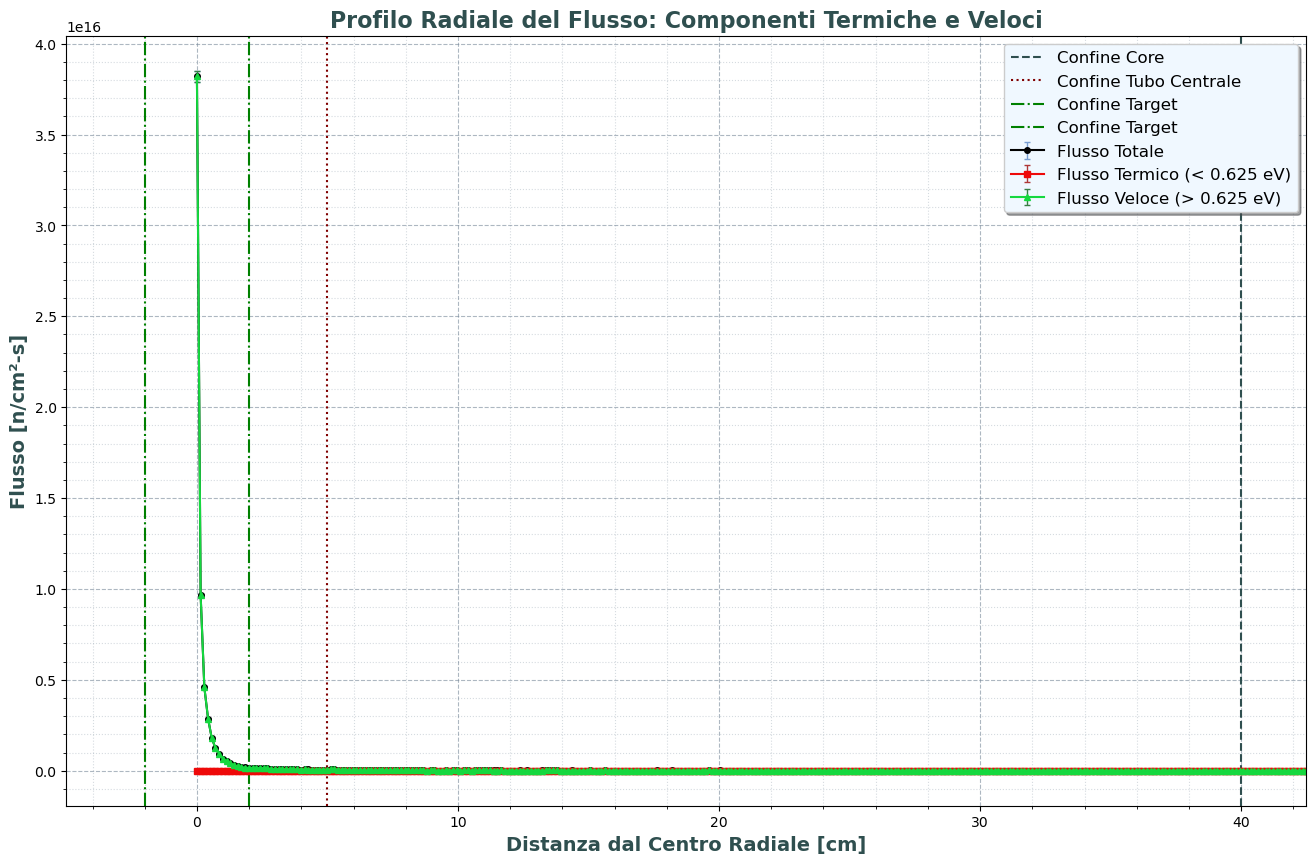

In [10]:
# --- 1. RECUPERO DATI TALLIES ---
tally_term = sp.get_tally(name='flusso_termico')
tally_vel = sp.get_tally(name='flusso_veloce')

# Estrazione e reshape
flux_term = tally_term.get_values(scores=['flux'], value='mean').reshape((bin_ris, bin_ris))
std_term = tally_term.get_values(scores=['flux'], value='std_dev').reshape((bin_ris, bin_ris))

flux_vel = tally_vel.get_values(scores=['flux'], value='mean').reshape((bin_ris, bin_ris))
std_vel = tally_vel.get_values(scores=['flux'], value='std_dev').reshape((bin_ris, bin_ris))

# Normalizzazione S/V
flux_term *= S/V
std_term *= S/V
flux_vel *= S/V
std_vel *= S/V

flux_tot = flux_term + flux_vel
std_tot = np.sqrt(std_term**2 + std_vel**2)

mid_index = flux_tot.shape[0] // 2

def get_masked_radial(flux_2d, std_2d):
    f_rad = flux_2d[mid_index, :]
    s_rad = std_2d[mid_index, :]
    f_masked = np.ma.masked_where(f_rad > 1e18, f_rad)
    return f_masked, s_rad

rad_flux_tot, rad_std_tot = get_masked_radial(flux_tot, std_tot)
rad_flux_term, rad_std_term = get_masked_radial(flux_term, std_term)
rad_flux_vel, rad_std_vel = get_masked_radial(flux_vel, std_vel)


# Creazione asse X
bound_xy = R_CORE + REF_SIDE/4
x_coords = np.linspace(0, bound_xy, bin_ris)

# --- 3. PLOTTING ---
fig, ax = plt.subplots(figsize=(16, 10))

# Serie di dati
ax.errorbar(x_coords, rad_flux_tot, yerr=rad_std_tot, fmt='-o', markersize=4,
            color='#000000', ecolor='#789DD1', capsize=2, elinewidth=1, 
            label='Flusso Totale')

ax.errorbar(x_coords, rad_flux_term, yerr=rad_std_term, fmt='-s', markersize=4,
            color="#EE0909", ecolor="#AE3737", capsize=2, elinewidth=1, 
            label='Flusso Termico (< 0.625 eV)')

ax.errorbar(x_coords, rad_flux_vel, yerr=rad_std_vel, fmt='-^', markersize=4,
            color="#15D83F", ecolor="#377D44", capsize=2, elinewidth=1, 
            label='Flusso Veloce (> 0.625 eV)')

# Linee verticali per confini fisici
ax.axvline(x=R_CORE, color='#2F4F4F', linestyle='--', alpha=1, label='Confine Core')
ax.axvline(x=R_PIPE, color='#800000', linestyle=':', alpha=1, label='Confine Tubo Centrale')
ax.axvline(x=R_TARGET, color='#008000', linestyle='-.', alpha=1, label='Confine Target')
ax.axvline(x=-R_TARGET, color='#008000', linestyle='-.', alpha=1, label='Confine Target')

# --- FORMATTAZIONE ---
ax.set_title('Profilo Radiale del Flusso: Componenti Termiche e Veloci', fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel('Distanza dal Centro Radiale [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel('Flusso [n/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')

ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
ax.set_xlim(-5, bound_xy)

plt.show()

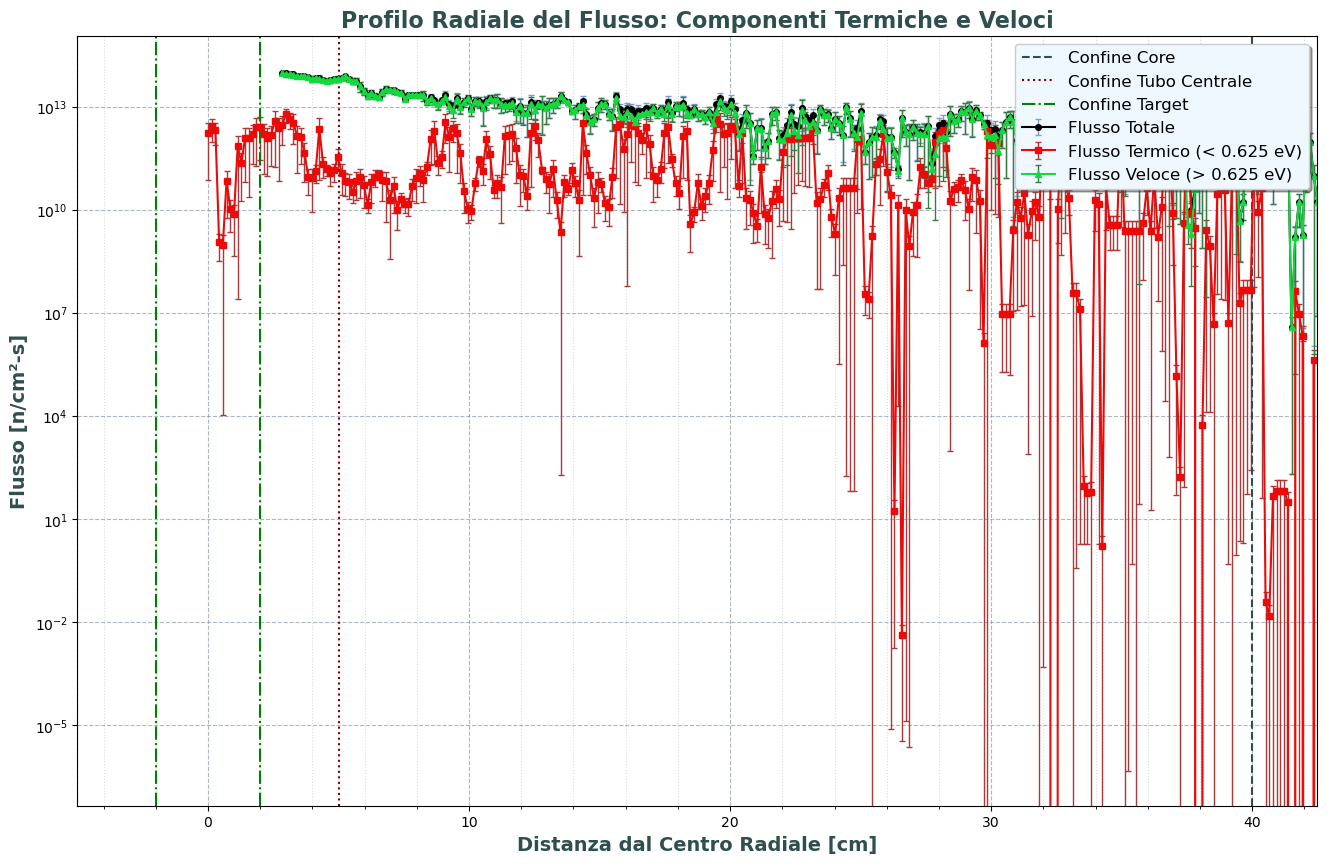

In [11]:
mid_index = flux_tot.shape[0] // 2

def get_masked_radial(flux_2d, std_2d):
    f_rad = flux_2d[mid_index, :]
    s_rad = std_2d[mid_index, :]
    f_masked = np.ma.masked_where(f_rad > 1e14, f_rad)
    return f_masked, s_rad

rad_flux_tot, rad_std_tot = get_masked_radial(flux_tot, std_tot)
rad_flux_term, rad_std_term = get_masked_radial(flux_term, std_term)
rad_flux_vel, rad_std_vel = get_masked_radial(flux_vel, std_vel)

# Creazione asse X
bound_xy = R_CORE + REF_SIDE/4
x_coords = np.linspace(0, bound_xy, bin_ris)

# --- 3. PLOTTING ---
fig, ax = plt.subplots(figsize=(16, 10))

# Serie di dati
ax.errorbar(x_coords, rad_flux_tot, yerr=rad_std_tot, fmt='-o', markersize=4,
            color='#000000', ecolor='#789DD1', capsize=2, elinewidth=1, 
            label='Flusso Totale')

ax.errorbar(x_coords, 1*rad_flux_term, yerr=rad_std_term, fmt='-s', markersize=4,
            color="#EE0909", ecolor="#AE3737", capsize=2, elinewidth=1, 
            label='Flusso Termico (< 0.625 eV)')

ax.errorbar(x_coords, rad_flux_vel, yerr=rad_std_vel, fmt='-^', markersize=4,
            color="#15D83F", ecolor="#377D44", capsize=2, elinewidth=1, 
            label='Flusso Veloce (> 0.625 eV)')

# Linee verticali per confini fisici
ax.axvline(x=-R_CORE, color='#2F4F4F', linestyle='--', alpha=1, label='Confine Core')
ax.axvline(x=R_CORE, color='#2F4F4F', linestyle='--', alpha=1)
ax.axvline(x=-R_PIPE, color='#800000', linestyle=':', alpha=1, label='Confine Tubo Centrale')
ax.axvline(x=R_PIPE, color='#800000', linestyle=':', alpha=1)
ax.axvline(x=-R_TARGET, color='#008000', linestyle='-.', alpha=1, label='Confine Target')
ax.axvline(x=R_TARGET, color='#008000', linestyle='-.', alpha=1)

# --- FORMATTAZIONE ---
ax.set_title('Profilo Radiale del Flusso: Componenti Termiche e Veloci', fontsize=16, fontweight='bold', color='#2F4F4F')
ax.set_xlabel('Distanza dal Centro Radiale [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel('Flusso [n/cm²-s]', fontsize=14, fontweight='bold', color='#2F4F4F')

ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
ax.set_yscale('log')

ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
ax.set_xlim(-5, bound_xy)

plt.show()

Valore massimo di fissioni: 8.38e+12 fiss/cm³-s
Valore minimo significativo di fissioni: 1.27e-22 fiss/cm³-s


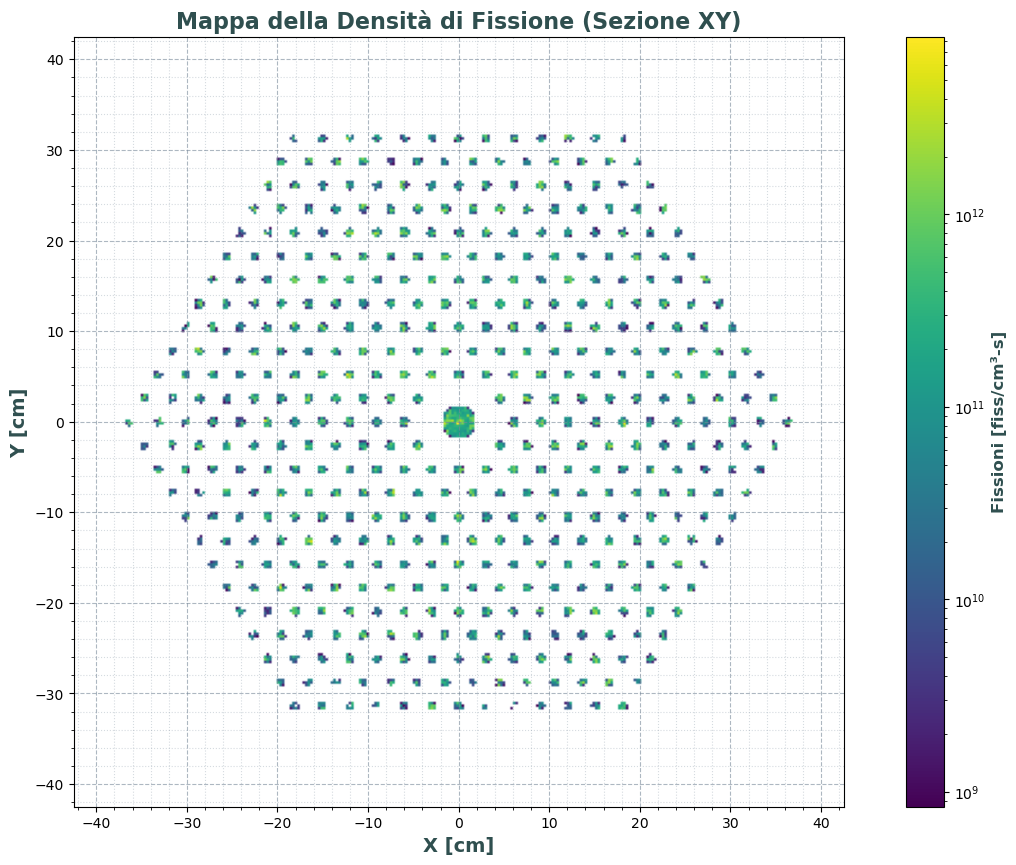

In [12]:
tally = sp.get_tally(name='mappa_fissioni')

# Estrazione e Mascheramento
data = tally.get_values(scores=['fission'], value='mean').reshape((bin_ris,bin_ris))

# Ricalcolo il mascheramento per sicurezza

data *= S/V # Applica fattore di scala 

# --- CALCOLO LIMITI PER IL PLOT ---
# Calcola il massimo reale della distribuzione
val_max = np.nanmax(data)
val_min = np.nanmin(data[data > 0])  # Ignora zeri per trovare il minimo significativo

print(f"Valore massimo di fissioni: {val_max:.2e} fiss/cm³-s")
print(f"Valore minimo significativo di fissioni: {val_min:.2e} fiss/cm³-s")

# Imposta il minimo a 4 ordini di grandezza sotto il massimo
# Questo evidenzia i gradienti nel combustibile tagliando il rumore di fondo
val_min = val_max * 1e-4

# tutti i valori inferiori di val min li elimino (mascheramento)
data = np.ma.masked_where(data < val_min, data) 

# PLOTTING
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE/4 

# Setup colormap
cmap = plt.cm.viridis
cmap.set_bad(color='white') 

# Imshow con vmin e vmax forzati
img = plt.imshow(data, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy], 
                 cmap=cmap, origin='lower',
                 norm=LogNorm(vmin=val_min, vmax=val_max)) 

# Formattazione Stile Unificato
plt.title('Mappa della Densità di Fissione (Sezione XY)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar = plt.colorbar(img)
cbar.set_label('Fissioni [fiss/cm³-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia personalizzata
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

Valore massimo di flusso: 1.65e+17 n/cm²-s
Valore minimo significativo di flusso: 8.28e-25 n/cm²-s


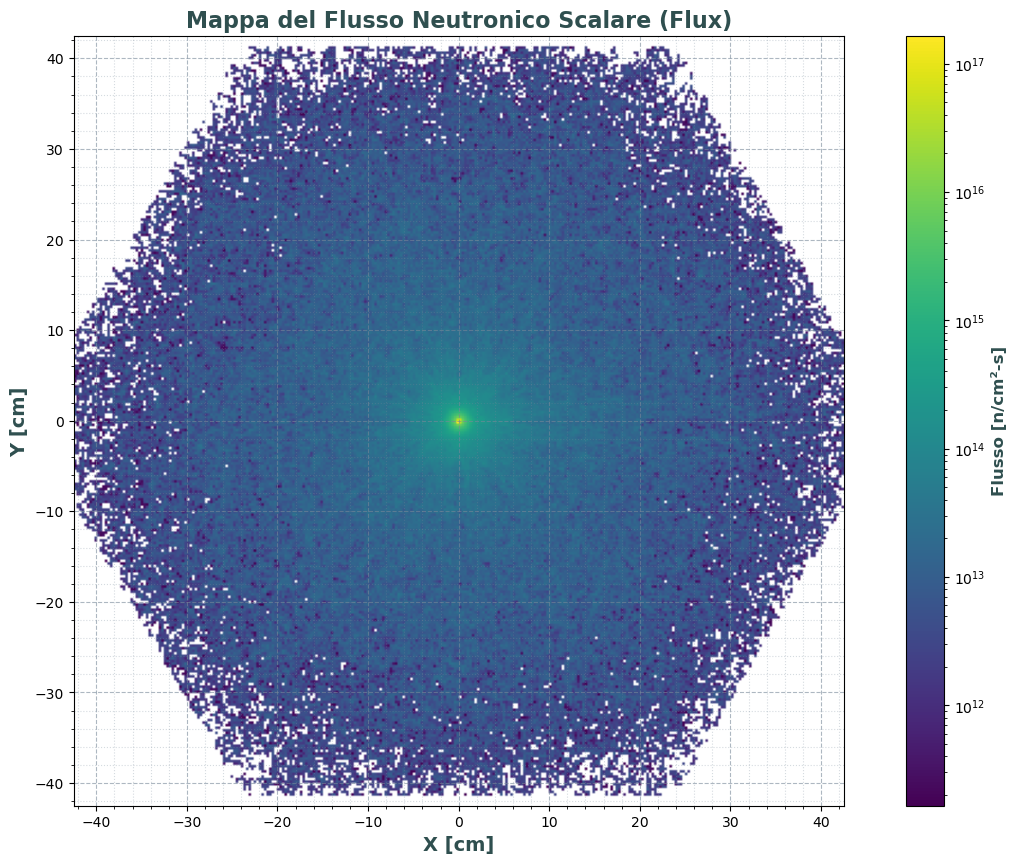

In [13]:
# --- 1. ESTRAZIONE DATI ---
tally_map_res = sp.get_tally(name='mappa_fissioni')

# Estrazione flux e reshape
flux_data = tally_map_res.get_values(scores=['flux'], value='mean').reshape((bin_ris, bin_ris))
flux_data *= S/V  # Normalizzazione con la sorgente

# --- CALCOLO RANGE DINAMICO ---
# 1. Trova il valore massimo reale (il picco di flusso)
val_max = np.nanmax(flux_data)
val_min = np.nanmin(flux_data[flux_data > 0])  # Ignora zeri per trovare il minimo significativo

print(f"Valore massimo di flusso: {val_max:.2e} n/cm²-s")
print(f"Valore minimo significativo di flusso: {val_min:.2e} n/cm²-s")

val_min = val_max * 1e-6

# 3. Maschera i valori sotto la soglia minima (diventano bianchi/trasparenti)
flux_masked = np.ma.masked_where(flux_data < val_min, flux_data)

# --- 2. PLOTTING ---
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE / 4 

# Setup Colormap
cmap = plt.cm.viridis
cmap.set_bad(color='white')

# Imshow con vmin e vmax forzati
img = plt.imshow(flux_masked, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy],
                 cmap=cmap, origin='lower',
                 norm=LogNorm(vmin=val_min, vmax=val_max)) 

# Formattazione
plt.title('Mappa del Flusso Neutronico Scalare (Flux)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar = plt.colorbar(img)
cbar.set_label('Flusso [n/cm²-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()


Valore massimo di assorbimenti: 2.32e+17 abs/cm³-s
Valore minimo significativo di assorbimenti: 7.72e-28 abs/cm³-s


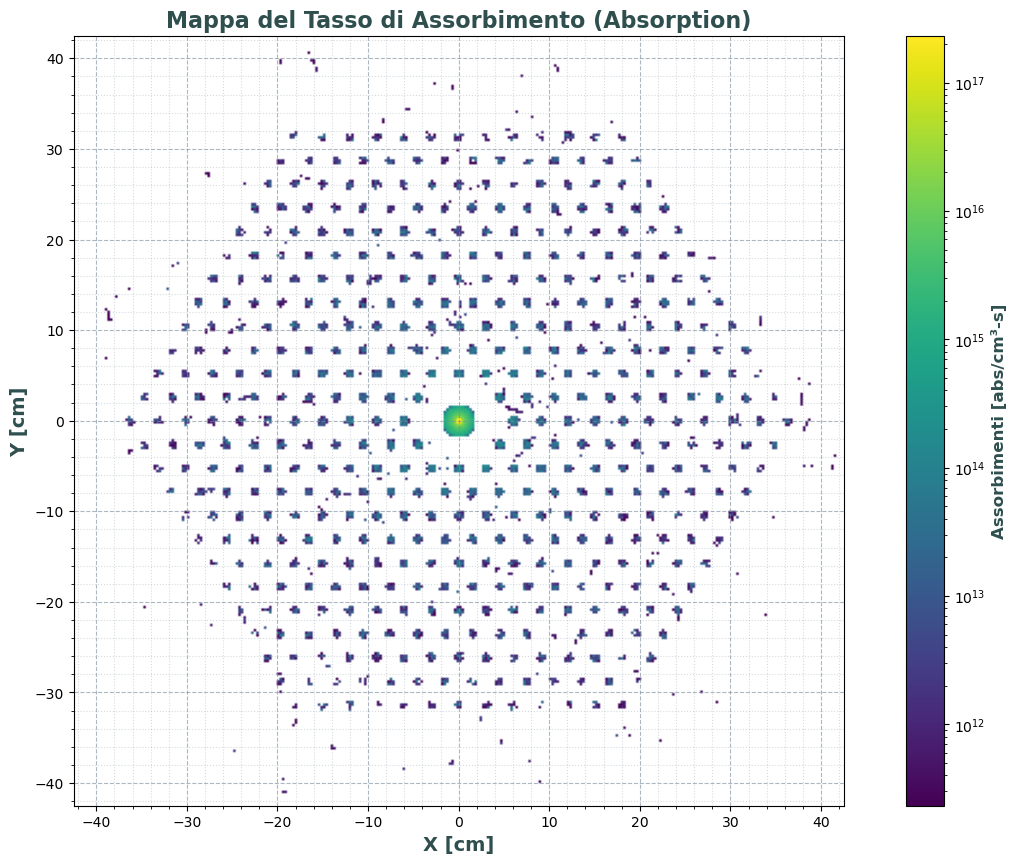

In [14]:
# --- RECUPERO DATI ---
tally_res = sp.get_tally(name='mappa_fissioni')

# 1. Estrazione Assorbimento
abs_data = tally_res.get_values(scores=['absorption'], value='mean').reshape((bin_ris, bin_ris))
abs_data *= S/V # Normalizzazione con la sorgente

val_max = np.nanmax(abs_data)
val_min = np.nanmin(abs_data[abs_data > 0])  # Ignora zeri per trovare il minimo significativo

print(f"Valore massimo di assorbimenti: {val_max:.2e} abs/cm³-s")
print(f"Valore minimo significativo di assorbimenti: {val_min:.2e} abs/cm³-s")

val_min = val_max * 1e-6 

abs_data = np.ma.masked_where(abs_data < val_min, abs_data)

# ==========================================
# PLOT 1: TASSO DI ASSORBIMENTO (Log Scale)
# ==========================================
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE / 4 # Uniformo l'extent agli altri plot
cmap = plt.cm.viridis
cmap.set_bad(color='white')

img1 = plt.imshow(abs_data, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy], 
                  cmap=cmap, origin='lower',
                  norm=LogNorm(vmin=val_min, vmax=val_max)) # Range forzato

# Stile
plt.title('Mappa del Tasso di Assorbimento (Absorption)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar1 = plt.colorbar(img1)
cbar1.set_label('Assorbimenti [abs/cm³-s]', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()


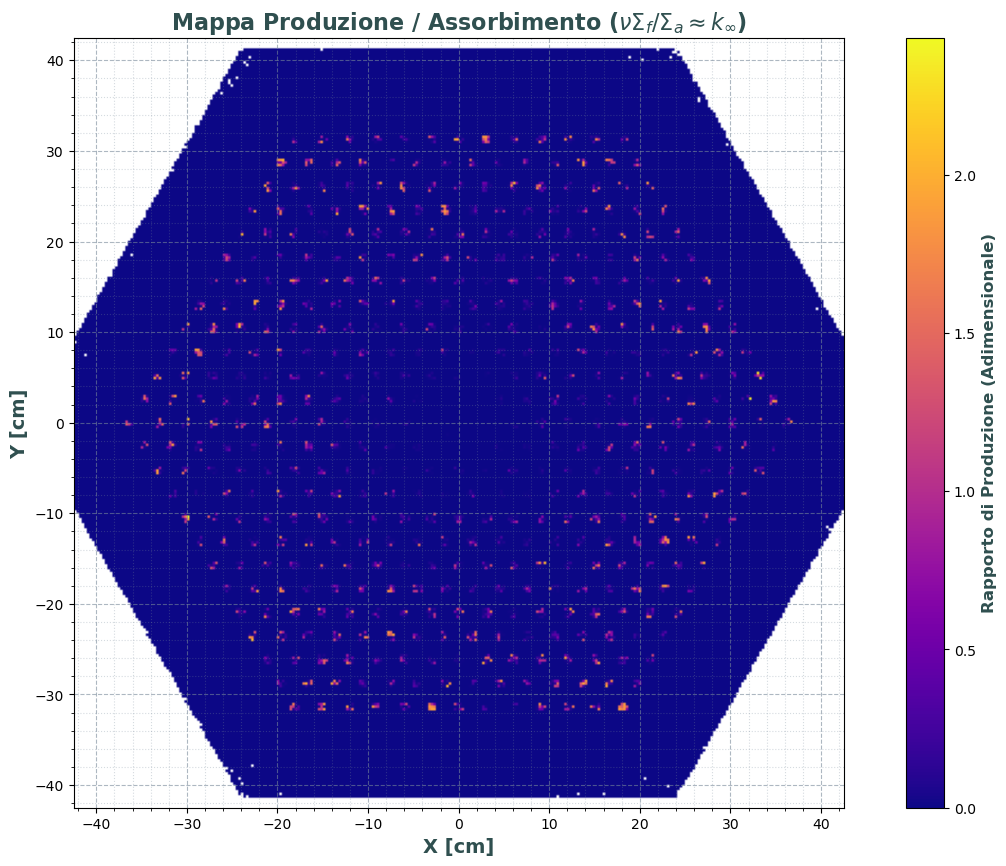

In [15]:
# --- 1. RECUPERO DATI (Nu-Fission e Absorption) ---
tally_res = sp.get_tally(name='mappa_fissioni')

# Nu-Fission (Numeratore)
nu_fiss_data = tally_res.get_values(scores=['nu-fission'], value='mean').reshape((bin_ris, bin_ris))

# Absorption (Denominatore) - Ricalcolo per sicurezza
abs_data_raw = tally_res.get_values(scores=['absorption'], value='mean').reshape((bin_ris, bin_ris))

# --- 2. CALCOLO DEL RAPPORTO (k_inf locale) ---
# Usiamo np.errstate per gestire silenziosamente la divisione per zero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_data = np.divide(nu_fiss_data, abs_data_raw)


# --- 4. PLOTTING ---
plt.figure(figsize=(16, 10))

bound_xy = R_CORE + REF_SIDE / 4 # Deve coincidere con l'extent degli altri plot

# Setup colormap
cmap = plt.cm.plasma # Plasma o Jet funzionano bene per heatmap di efficienza/reattività
cmap.set_bad(color='white') # I NaN (vuoto/riflettore) diventano bianchi

# PLOT
# NOTA FONDAMENTALE SUL VMAX:
# Il k_inf nel combustibile LWR varia tipicamente tra 0.8 (veleno) e 1.6 (fuel fresco).
# Se lasci automatico, un pixel rumoroso a valore 50 renderà tutto il grafico blu scuro.
# Blocchiamo vmax a 2.0 o 2.5 per vedere bene le differenze nel core.
img2 = plt.imshow(ratio_data, extent=[-bound_xy, bound_xy, -bound_xy, bound_xy], 
                  cmap=cmap, origin='lower',
                  vmin=np.nanmin(ratio_data), vmax=np.nanmax(ratio_data)) # vmax forzato al massimo reale del core

# Stile
plt.title(r'Mappa Produzione / Assorbimento ($\nu\Sigma_f / \Sigma_a \approx k_\infty$)', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('X [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel('Y [cm]', fontsize=14, fontweight='bold', color='#2F4F4F')

# Colorbar
cbar2 = plt.colorbar(img2)
cbar2.set_label('Rapporto di Produzione (Adimensionale)', fontsize=12, fontweight='bold', color='#2F4F4F')

# Griglia
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

plt.show()

In fisica dei reattori, la letargia ($u$) è una variabile adimensionale logaritmica che descrive la perdita di energia di un neutrone durante il processo di moderazione.

Man mano che il neutrone perde energia ($E$ decresce), la sua letargia ($u$) aumenta. Esprime letteralmente il grado di "stanchezza" o rallentamento del neutrone.

Quando tracci uno spettro con l'energia su scala logaritmica (asse X) e $\Phi(u)$ su scala lineare (asse Y), l'area geometrica sotto la curva rappresenta il flusso totale integrato

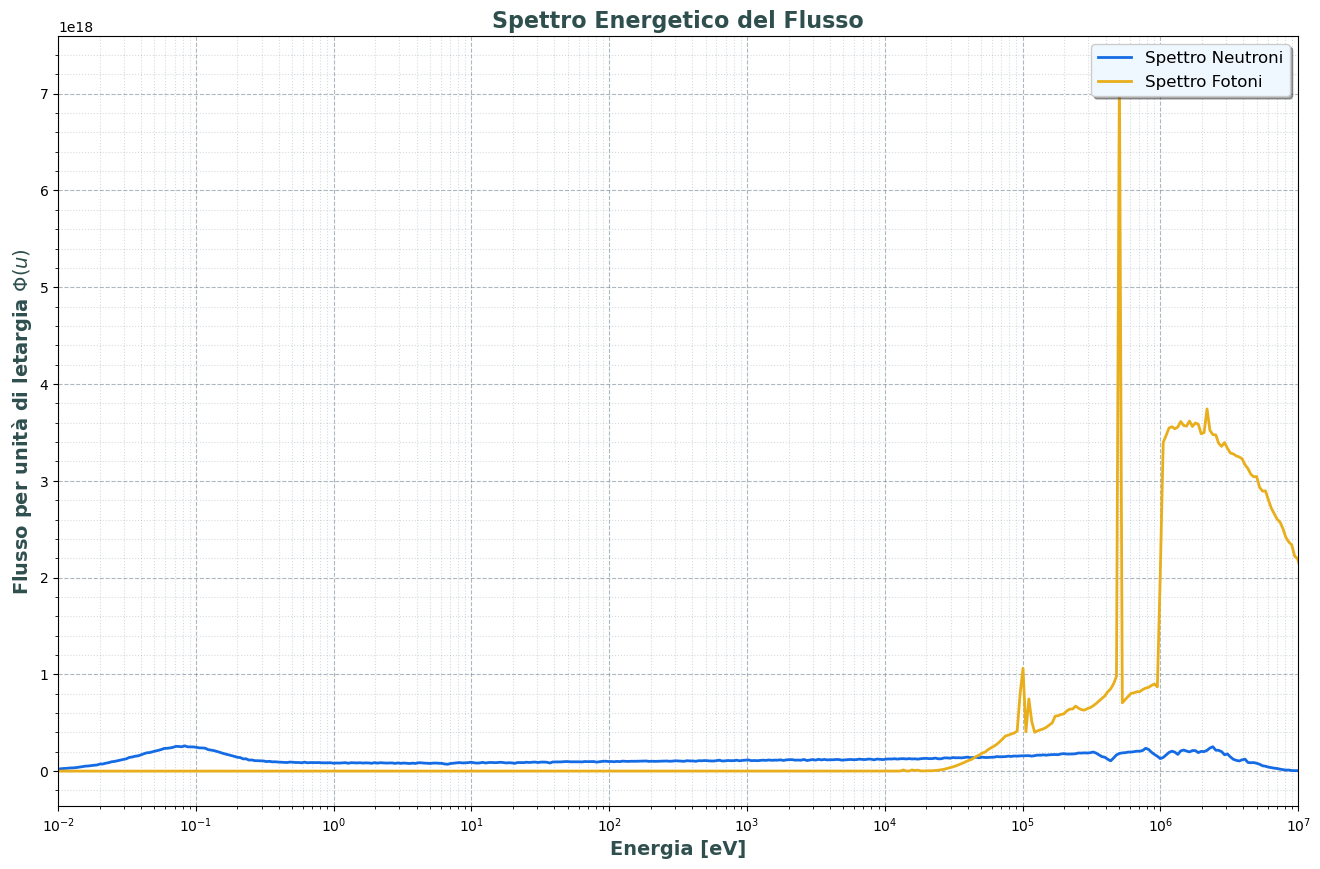

In [17]:
tally_spec_res = sp.get_tally(name='spettro_energetico')

# Estrazione sicura filtrando nativamente tramite get_values()
# La shape estratta sarà esattamente (500, 1) per ogni particella, facilmente appiattibile a (500,)
flux_n = tally_spec_res.get_values(
    scores=['flux'], 
    filters=[openmc.ParticleFilter], 
    filter_bins=[('neutron',)], 
    value='mean'
).flatten()

flux_p = tally_spec_res.get_values(
    scores=['flux'], 
    filters=[openmc.ParticleFilter], 
    filter_bins=[('photon',)], 
    value='mean'
).flatten()

# Flusso totale
flux_tot = flux_n + flux_p

# Asse energetico
energy_bins = np.logspace(-3, 7.6, 501)
energy_mid = np.sqrt(energy_bins[1:] * energy_bins[:-1]) 

# Calcolo Flusso per unità di letargia: \Phi(u) = \Phi / \ln(E_{i+1} / E_i)
lethargy_widths = np.log(energy_bins[1:] / energy_bins[:-1])

# Assumendo che 'S' sia il fattore di normalizzazione della sorgente definito precedentemente
flux_per_lethargy_tot = (flux_tot * S) / lethargy_widths
flux_per_lethargy_n = (flux_n * S) / lethargy_widths
flux_per_lethargy_p = (flux_p * S) / lethargy_widths

plt.figure(figsize=(16, 10))

# Plot
#plt.semilogx(energy_mid, flux_per_lethargy_tot, color='#000000', linewidth=2, label='Spettro Totale')
plt.semilogx(energy_mid, flux_per_lethargy_n, color="#146BE4", linewidth=2, label='Spettro Neutroni')
plt.semilogx(energy_mid, flux_per_lethargy_p, color="#E9AE1B", linewidth=2, label='Spettro Fotoni')

plt.title('Spettro Energetico del Flusso', fontsize=16, fontweight='bold', color='#2F4F4F')
plt.xlabel('Energia [eV]', fontsize=14, fontweight='bold', color='#2F4F4F')
plt.ylabel(r'Flusso per unità di letargia $\Phi(u)$', fontsize=14, fontweight='bold', color='#2F4F4F')

plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
plt.minorticks_on()
plt.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
plt.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
plt.xlim(1e-2, 1e7)

plt.show()

In [18]:

tally_fiss = sp.get_tally(name='fission_tot')
# Prendo il valore medio dello score 'fission' (fissioni per particella sorgente)
fission_per_source_particle = tally_fiss.get_slice(scores=['fission']).mean.flatten()[0]

E_f_joule = 200.0 * 1e6 * 1.6022e-19 # Energia per fissione in Joule (~3.204e-11 J)

# Calcolo Tasso di Fissione e Potenza
tasso_fissione = fission_per_source_particle * S # [fissioni / s]
potenza_termica_W = tasso_fissione * E_f_joule    # [Watt]
potenza_termica_MW = potenza_termica_W / 1e6      # [MW]

print(f"Fissioni per particella sorgente: {fission_per_source_particle:.5e}")
print(f"Tasso di fissione reale:          {tasso_fissione:.5e} fissioni/s")
print(f"Potenza termica totale:           {potenza_termica_MW:.3f} MW")

# COP = Potenza termica del reattore / Potenza elettrica sincrotrone
potenza_elettrica_sincrotrone = 0.2 # dato di riferimento paper lorenzo per avere il valore di S impostato
efficienza = 0.5 # Efficienza di conversione da termica a elettrica (ipotetica)
COP = potenza_termica_MW / (potenza_elettrica_sincrotrone / efficienza)    
print(f"Coefficient of Performance (COP): {COP:.3f}")

LookupError: Unable to get Tally